In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import mdtraj

In [2]:
u = mda.Universe("../pdbs/trim5-public-master-CG-paper-pdbs/aligned/EM_test_3/npt_berendsen_thinned.gro",
                 "../pdbs/trim5-public-master-CG-paper-pdbs/aligned/EM_test_3/npt_berendsen_thinned.xtc")

#I'll assign resids 290 - 493 to SPRY, I'll assign 1000 + 1 to 231 for each 
#u.residues.resids = list(arange(290,494)) \
#                    + list(arange(1001,1232))\
#                    + list(arange(2001,2232))\
#                    + list(arange(3001,3232))\
#                    + list(arange(4001,4232))\
#                    + list(arange(5001,5232))\
#                    + list(arange(6001,6232))\
#                    + list(arange(7001,7232))\
#                    + list(arange(8001,8232))\
#                    + list(arange(9001,9232))\
#                    + list(arange(10001,10232))\
#                    + list(arange(11001,11232))\
#                    + list(arange(12001,12232))\
#                    + list(arange(13001,13232))\
#                    + list(arange(14001,14232))\
#                    + list(arange(15001,15232))\
#                    + list(arange(16001,16232))\
#                    + list(arange(17001,17232))\
#                    + list(arange(18001,18232))
u.residues.resids = arange(len(u.residues))

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)


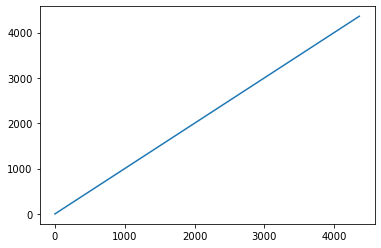

In [3]:
plot(u.residues.resids)

In [6]:
import numpy as np

def contact_size(system):
    '''The function calculates the size of the vector needed to contain contact map '''
    counter = 0
    for res1 in system.residues:
        for res2 in system.residues:
            if abs(res1.resid - res2.resid) > 1 and res1.resid < res2.resid:
                counter += 1
    return counter
def contact_map2(system, stride,sel="protein",cutoff = 3.5):
    ''' Faster!!! The function creates contact map (0 and 1) for for every pair of aminoacids'''
    sel_heavy = sel
    num_data_points = (len(system.trajectory) // stride) + (0 if (len(system.trajectory) % stride == 0) else 1)
    size = contact_size(system.select_atoms(sel))
    contacts = np.empty((num_data_points, size), dtype=np.float)
    slices = []
    min_i = 0
    max_i = 0
    for res in system.select_atoms(sel).residues:
        max_i = min_i + res.atoms.select_atoms(sel_heavy).n_atoms
        slices.append((min_i, max_i))
        min_i = max_i

    #print(slices)
    heavy_system = system.select_atoms(sel_heavy)
    index = 0
    for ts in system.trajectory[::stride]:
        if ts.frame % 100 == 0 :
            output = round(100 * ts.frame / len(system.trajectory), 1)
            print(output,"% complete",end='\r')
            sys.stdout.flush()
        contact_map = np.zeros(size, dtype=np.float)
        contact_matrix = MDAnalysis.analysis.distances.contact_matrix(heavy_system.atoms.positions, cutoff = cutoff)
        counter = 0
        for i, res1 in enumerate(slices):
            i1 = res1[0]
            i2 = res1[1]
            for j, res2 in enumerate(slices):
                if abs(i - j) > 1 and i < j:
                    j1 = res2[0]
                    j2 = res2[1]
                    if np.any(contact_matrix[i1:i2, j1:j2]):
                        contact_map[counter] = 1.
                    counter += 1
        contacts[index,:] = contact_map
        index += 1
    return contacts


def getContacts(systems,datasets,selection_strings,stride=10,EQPOINT=250,cutoff = 3.5):
    
    contacts=[]
    stderrs=[]
    allcontacts=[]
    for i in range(len(datasets)):
        subcontacts=[]
        for j in range(len(datasets[i])):
            cont = contact_map2(systems[i][j],stride,sel = selection_strings[i][j],cutoff = cutoff)
            subcontacts.append(cont)
            #print(cont.shape)
        print(subcontacts)
        #contacts.append(mean(mean(subcontacts,axis = 0)[EQPOINT:],axis=0))
        allcontacts.append(subcontacts)
    
    return allcontacts

#contacts = getContacts([[u]],[[u.select_atoms("protein")]],[["protein"]],stride = 10, EQPOINT = 0, cutoff = 3.5)

In [5]:
contacts = contact_map2(u,10,sel = "protein and not name H*", cutoff = 4.5)

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:521: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(len(group), dtype=np.bool)
<ipython-input-4-8af248e1f457>:16: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  contacts = np.empty((num_data_points, size), dtype=np.float)


<ipython-input-4-8af248e1f457>:33: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  contact_map = np.zeros(size, dtype=np.float)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\lib\distances.py:712: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-n

KeyboardInterrupt: 

In [ ]:
def BestTwoD(array1d):
    #The number of dimensions (excluding nearest neighbours and self)
    N = int(1.5 + .5*np.sqrt(1+(8*len(array1d))))

    #Construct a 2D version of the contact map (it excludes nearesty neighbours and self, but there are still NxN slots)
    twoD=zeros((N,N))            
    j=2
    k=0
    for i in range(len(array1d)):
        if abs(j-k)>1:
            twoD[j][k] = array1d[i]
            twoD[k][j] = array1d[i]
        j+=1
        if j == len(twoD):
            k+=1
            j = k+2
            if k==len(twoD)-2 and j >len(twoD)-2 :
                break
    return twoD


contacts_2d = BestTwoD(mean(contacts,axis = 0))

In [ ]:
figure(figsize = (20,100))
imshow(contacts_2d,origin = "lower",cmap = "seismic")
ylim(0,205)

In [ ]:
figure(figsize = (20,20))
imshow(contacts_2d[:493-290,:493-290+1],origin = "lower")

In [ ]:
i=1
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=2
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=3
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)
axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=4
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)
axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=5
nspry = 494-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=6
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=7
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=8
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=9
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=10
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=11
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=12
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=13
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=14
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=15
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=16
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
i=17
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")
axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:


i=18
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)


axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


In [ ]:
figure(figsize = (20,500))
imshow(contacts_2d[:,:nspry],origin = "lower",extent = (289.5,493.5,u.residues.resids[0]-.5,u.residues.resids[-1]+.5),cmap = 'binary')


axvspan(326,349,color = "green",alpha = 0.1)
axvspan(380,400,color = "blue",alpha = 0.1)
axvspan(415,425,color = "orange",alpha = 0.1)


axvline(334,color = "red")

In [ ]:
mean_over_cas_spry_contacts=0
for i in range(18):
    mean_over_cas_spry_contacts+=contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))]
mean_over_cas_spry_contacts/=18